In [19]:
l = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

res_list = []
for i in l:
    res_list.append(i+i*(0.08))
print(res_list)
print()

import numpy as np
arr = np.array(l)
tax_arr = arr+arr*0.08
print(tax_arr)
print()

thr_arr = tax_arr[tax_arr>5]
print(thr_arr)
print()

arr2 = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
print(arr2)
print()
col_sum_arr = arr2.sum(axis=0)
print(col_sum_arr)

print()
row_sum_arr = arr2.sum(axis=1)
print(row_sum_arr)

[1.08, 2.16, 3.24, 4.32, 5.4, 6.48, 7.5600000000000005, 8.64, 9.72, 10.8, 11.88, 12.96, 14.04, 15.120000000000001, 16.2, 17.28, 18.36, 19.44, 20.52, 21.6]

[ 1.08  2.16  3.24  4.32  5.4   6.48  7.56  8.64  9.72 10.8  11.88 12.96
 14.04 15.12 16.2  17.28 18.36 19.44 20.52 21.6 ]

[ 5.4   6.48  7.56  8.64  9.72 10.8  11.88 12.96 14.04 15.12 16.2  17.28
 18.36 19.44 20.52 21.6 ]

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

[15 18 21 24]

[10 26 42]


In [63]:
# Task 2  —  Load & Explore
# PILLAR: PANDAS ESSENTIALS
# Objective: Analyse data with Pandas — loading, filtering, grouping, and aggregation
# Create a small CSV file (at least 15 rows) representing employees: name, department, salary, years_experience. You can generate it in code with pandas.DataFrame.to_csv(), or type it by hand.
# 1.	Read the CSV into a DataFrame with pd.read_csv() and print df.info() and df.describe().
# 2.	Filter the DataFrame to a single department using boolean indexing, and separately using .query().
# 3.	Group by department and compute the average salary and headcount per department using a single .agg(...) call with named results.
# 4.	Sort the grouped result by average salary, descending.
# Acceptance criteria
# Both filtering approaches (boolean indexing and .query()) must return the same rows. The final grouped summary must be sorted by average salary in descending order.

import pandas as pd

data = {
    'Name': ['Varshith', 'Vinaya', 'Aish', 'Ajay', 'Prasanna', 'Varshith', 'Vinaya', 'Aish', 'Ajay', 'Prasanna', 'Varshith', 'Vinaya', 'Aish', 'Ajay', 'Prasanna'],
    'Dept': ['IT', 'HR', 'Marketing', 'Sales', 'Maintainance', 'IT', 'HR', 'Marketing', 'Sales', 'Maintainance', 'IT', 'HR', 'Marketing', 'Sales', 'Maintainance'],
    'Salary': [30000, 35000, 25000, 40000, 35000, 30000, 35000, 25000, 40000, 35000, 30000, 35000, 25000, 40000, 35000],
    'years_experience': [1, 1, 2, 2, 3, 1, 1, 2, 2, 3, 1, 1, 2, 2, 3]
}
df = pd.DataFrame(data)
df.to_csv('employees.csv', index=False)
df = pd.read_csv('employees.csv')
print(df)
print()
print('Info: ')
df.info()
print('Describe: \n', df.describe())

filt_data = df[df['Dept'] == 'IT']
print('Indexing: ', filt_data)
filt_data1 = df.query("Dept == 'IT'")
print('Quering: ', filt_data1)

group_data = df.groupby("Dept").agg(avg_sal = ('Salary', 'mean'), headcount = ('Name', "count"))
print(group_data)

group_sort_data = group_data.sort_values(by='avg_sal', ascending=False)
print(group_sort_data)

        Name          Dept  Salary  years_experience
0   Varshith            IT   30000                 1
1     Vinaya            HR   35000                 1
2       Aish     Marketing   25000                 2
3       Ajay         Sales   40000                 2
4   Prasanna  Maintainance   35000                 3
5   Varshith            IT   30000                 1
6     Vinaya            HR   35000                 1
7       Aish     Marketing   25000                 2
8       Ajay         Sales   40000                 2
9   Prasanna  Maintainance   35000                 3
10  Varshith            IT   30000                 1
11    Vinaya            HR   35000                 1
12      Aish     Marketing   25000                 2
13      Ajay         Sales   40000                 2
14  Prasanna  Maintainance   35000                 3

Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dty

In [73]:
# Task 3  —  Join the Data
# PILLAR: MERGING & MISSING DATA
# Objective: Merge DataFrames and handle missing data sensibly
# Create a second small DataFrame, departments, with columns department (matching the names used in Task 2) and department_budget.
# 1.	Merge your employees DataFrame from Task 2 with departments on the department column using an inner join.
# 2.	Add at least one employee whose department does NOT exist in the departments table, then redo the merge as a left join — observe the resulting NaN values.
# 3.	Introduce at least two missing values into your salary or years_experience column (e.g. using numpy.nan), then detect them with .isna().sum().
# 4.	Handle the missing values with a justified choice: either drop those rows or fill them (e.g. with the column mean) — write a one-sentence comment explaining why you chose that approach for this specific column.
# Acceptance criteria
# The left join must show NaN for the unmatched employee's department_budget, while the inner join excludes that row entirely. The missing-data handling must include a written justification, not just the code.

depts_data = {'Dept': ['IT', 'HR', 'Marketing', 'Sales', 'Maintainance'],
              'department_budget': [800000, 500000, 400000, 200000, 300000]
             }
df1 = pd.DataFrame(depts_data)
df1.to_csv('Departments.csv', index=False)
df1 = pd.read_csv('Departments.csv')
print(df1)

inner_join = pd.merge(df, df1, on='Dept', how='inner')
print(inner_join)

new_emp = pd.DataFrame({
     'Name': ['Vinay'],
     'Dept': ['Research'],
     'Salary': [33000],
     'years_experience': [2]
})

employees = pd.concat([df, new_emp], ignore_index = True)
left_join = pd.merge(employees, df1, on='Dept', how='left')
print(left_join[left_join['Dept'] == 'Research'])

employees.loc[1, 'Salary'] = np.nan
employees.loc[5, 'years_experience'] = np.nan
print("\nMissing Values Count:")
print(employees.isna().sum())

# 4. Handle missing values
employees['Salary'] = employees['Salary'].fillna(
    employees['Salary'].mean()
)

employees['years_experience'] = employees['years_experience'].fillna(
    employees['years_experience'].mean()
)
print("\nData After Filling Missing Values:")
print(employees)

           Dept  department_budget
0            IT             800000
1            HR             500000
2     Marketing             400000
3         Sales             200000
4  Maintainance             300000
        Name          Dept  Salary  years_experience  department_budget
0   Varshith            IT   30000                 1             800000
1     Vinaya            HR   35000                 1             500000
2       Aish     Marketing   25000                 2             400000
3       Ajay         Sales   40000                 2             200000
4   Prasanna  Maintainance   35000                 3             300000
5   Varshith            IT   30000                 1             800000
6     Vinaya            HR   35000                 1             500000
7       Aish     Marketing   25000                 2             400000
8       Ajay         Sales   40000                 2             200000
9   Prasanna  Maintainance   35000                 3             30000

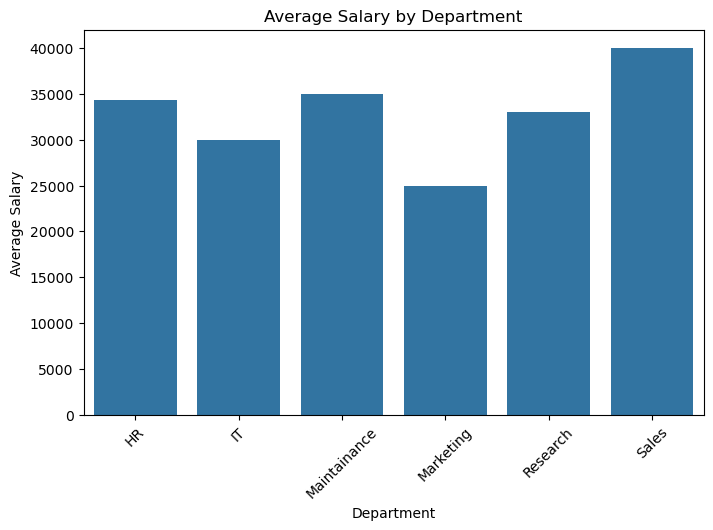

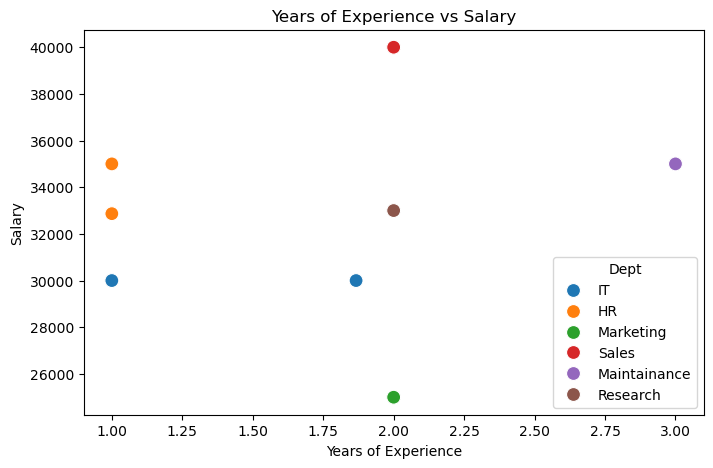

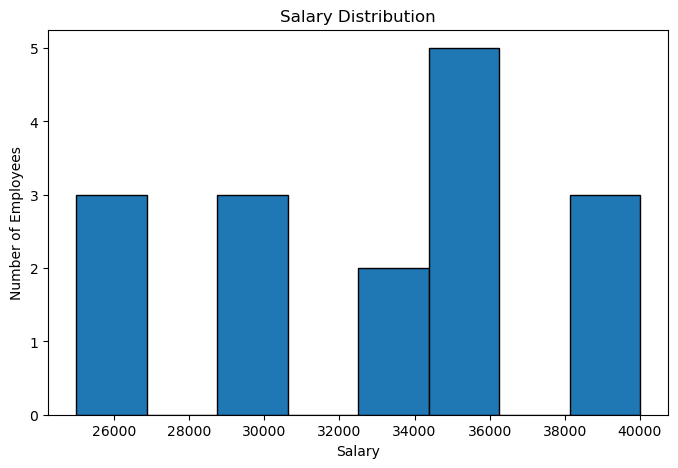

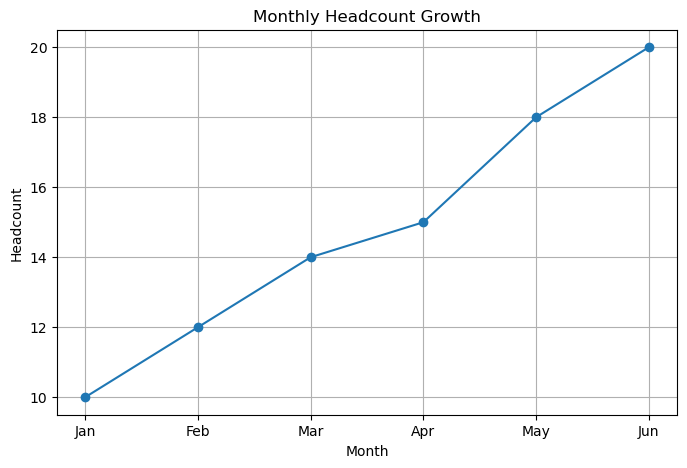

In [74]:
# Task 4  —  Tell a Story
# PILLAR: VISUALIZATION
# Objective: Create charts to communicate insights
# Using the employees DataFrame you've built up through Tasks 2–3:
# 1.	Create a bar chart comparing average salary across departments.
# 2.	Create a scatter plot of years_experience vs. salary, colored (hue) by department.
# 3.	Create a histogram showing the distribution of salaries across all employees.
# 4.	For each chart, write one sentence explaining what QUESTION that specific chart type answers that the others don't.
# Acceptance criteria
# All three charts must render without errors and have a title and axis labels. The three one-sentence explanations must correctly distinguish each chart's purpose (comparison vs. relationship vs. distribution).

# Stretch goal: add a line chart showing a trend (e.g. simulate monthly headcount growth) and explain why a line chart fits a trend better than a bar chart would.


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# 1. Bar Chart
# ==========================

avg_salary = employees.groupby('Dept')['Salary'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_salary, x='Dept', y='Salary')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.show()


# ==========================
# 2. Scatter Plot
# ==========================

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=employees,
    x='years_experience',
    y='Salary',
    hue='Dept',
    s=100
)

plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()


# ==========================
# 3. Histogram
# ==========================

plt.figure(figsize=(8, 5))
plt.hist(employees['Salary'], bins=8, edgecolor='black')

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.show()


# ==========================
# Stretch Goal: Line Chart
# ==========================

monthly_headcount = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Headcount': [10, 12, 14, 15, 18, 20]
})

plt.figure(figsize=(8, 5))
plt.plot(
    monthly_headcount['Month'],
    monthly_headcount['Headcount'],
    marker='o'
)

plt.title('Monthly Headcount Growth')
plt.xlabel('Month')
plt.ylabel('Headcount')
plt.grid(True)
plt.show()

In [77]:
# Task 5  —  Consolidation Reflection
# PILLAR: 10-DAY RECAP
# Objective: Connect all six master classes to upcoming Bootcamp modules
# In writing (a short document, or comments in a script — whichever your trainer prefers), answer the following:
# 1.	Name one specific Java habit you had to unlearn or adjust in each of: OOP (Master Class 4), FastAPI/testing (Master Class 5), and Pandas/NumPy (Master Class 6).
# 2.	Pick one skill from this week (e.g. vectorized NumPy operations, Pydantic validation, or DataFrame filtering) and describe, in 2–3 sentences, where you expect to see it again in the upcoming ML/DL/LLM/Agentic modules.
# 3.	Identify the ONE topic from the last six classes you feel least confident about, and one concrete action you'll take to shore it up before the readiness assessment.
# Acceptance criteria
# All three answers are specific and reference actual concepts covered (not generic statements). The self-identified weak topic should be genuinely reflected upon, not a throwaway answer.

# Answers
# 1. OOP
# 2. Pandas Data manipulation
# 3. Python numpy and pandas

In [78]:
# Task 6  —  Readiness Self-Check
# PILLAR: READINESS ASSESSMENT
# Objective: Demonstrate readiness via a short quiz/coding test
# Before the graded readiness assessment, complete this ungraded practice round to identify gaps early.
# 1.	Without looking anything up, write from memory: a class with a constructor and one dunder method; a FastAPI endpoint with a Pydantic request model; and a Pandas groupby().agg(...) call.
# 2.	Check your answers against the earlier master-class materials (slides, trainer guide, or live-demo files) and note any mistakes.
# 3.	For each mistake found, write one sentence on why it happened (typo, misremembered syntax, conceptual gap) — this distinction matters for how you study before the real assessment.

class Employee:
    def __init__(self, name, salary):
        self.name = name
        self.salary = salary

    def __str__(self):
        return f"Employee(name={self.name}, salary={self.salary})"


emp = Employee("Varshith", 30000)
print(emp)

from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

class EmployeeRequest(BaseModel):
    name: str
    salary: float

@app.post("/employee")
def create_employee(employee: EmployeeRequest):
    return {
        "message": "Employee created",
        "employee": employee
    }


import pandas as pd

summary = (
    df.groupby("Dept")
      .agg(
          average_salary=("Salary", "mean"),
          headcount=("Name", "count")
      )
)

print(summary)

Employee(name=Varshith, salary=30000)


ModuleNotFoundError: No module named 'fastapi'